In [27]:
from PySide2.QtCore import QTimer, QTime, Signal
import time
import numpy as np
import os
import os
import sys

# Get the absolute path of the current script
script_path = os.path.abspath(r"C:\Users\YY3\GIT\squdi\src\qudi\jupyternotebooks\hom")
# Get the directory name of the script path
script_dir = os.path.dirname(script_path)
# Change the working directory to the script's directory
os.chdir(script_dir)

from hom.auto import *
from hom.tools import *
%gui qt

In [28]:
folder_save = r'Z:\Vlad\SnV\TPI\Electrodes_e4\F1\atto3_D1\g2_atto3'
current_cryo = 'atto3'
non_active_cryo = 'bf'
integrate_for_mins = 2
values = [30e3]

params = {
    'timetaggerlogic': timetaggerlogic,
    'timetagger': timetagger,
    'poi_manager_logic_remote': poi_manager_logic_remote,
    'switchlogic': switchlogic,
    'ibeam_smart_remote': ibeam_smart_remote,
    'powercontroller_logic': powercontroller_logic,
    'integrate_for_mins': integrate_for_mins,
    'current_cryo': current_cryo,
    'non_active_cryo': non_active_cryo,
    'folder_save': folder_save,
    'values': values,
}
# measurement_g2 = MeasurementsBase(**params)  
measurement_g2 = CorrMeasurements(**params)  

In [10]:
measurement_g2.set_green_power('atto3', 30e3) #ensure the starting power is high for refocus

In [9]:
measurement_g2.set_green_power('atto3', 30e3) #ensure the starting power is high for refocus
measurement_g2.start_integration(integrate_for_mins = 90, start_delay = 10000)

In [10]:
measurement_g2.stop_all_timers()

AttributeError: 'CorrMeasurements' object has no attribute 'timer'

In [29]:
folder_save = r'Z:\Vlad\SnV\TPI\Electrodes_e4\F1\atto3_D1\test_auto_e_hom0'
current_cryo = 'atto3' #fix the notation of current and non-active cryo
non_active_cryo = 'bf'
integrate_for_mins = 180
values = [0, -.2, -.5, -0.8, -1.13]  #the counts have to be equalized!

params = {
    'ple_gui': ple_gui,
    'laser_scanner_logic': laser_scanner_logic,
    'scanner_gui' : scanner_gui,
    'scanning_data_logic' : scanning_data_logic,
    'pulsestreamer' : pulsestreamer,
    'timetaggerlogic': timetaggerlogic,
    'timetagger': timetagger,
    'poi_manager_logic_remote': poi_manager_logic_remote,
    'switchlogic': switchlogic,
    'ibeam_smart_remote': ibeam_smart_remote,
    'powercontroller_logic': powercontroller_logic,
    'integrate_for_mins': integrate_for_mins,
    'current_cryo': current_cryo,
    'non_active_cryo': non_active_cryo,
    'folder_save': folder_save,
    'values': values,
}

In [14]:
measurement_e_hom = StarkHOM(ao_electrodes_remote, **params)  

In [39]:
current_range = laser_scanner_logic.scan_ranges['a']

In [5]:
laser_scanner_logic

<qudi.logic.ple.ple_scanner_logic.PLEScannerLogic(0x246bd197ee0) at 0x00000246C0CDF940>

In [67]:
zpl_calibration = {}
v0 = -0.5
dv = 0.6
zpl_calibration['freq'] = []
zpl_calibration['setpoint'] = np.linspace(v0 - dv/2, v0 + dv/2, 25)

In [68]:
for _setpoint in zpl_calibration['setpoint']:
    ao_electrodes_remote.setpoint = _setpoint
    ple_gui._mw.channel_comboBox.setCurrentText('APD4')
    res_atto3 = do_ple_scan(laser_scanner_logic, ple_gui, lines=1, in_range=current_range)
    zpl_calibration['freq'].append(res_atto3.best_values['center'])
    
# zpl_calibration['freq'] = np.array(zpl_calibration['freq'])

Rsquared 0.9069698867393908
Rsquared 0.9149060749012602
Rsquared 0.9359030945024966
Rsquared 0.9049377040484898
Rsquared 0.9353285516676606
Rsquared 0.8365486758152889
Rsquared 0.7587072558940442
Rsquared 0.9417458575853435
Rsquared 0.9500292020837872
Rsquared 0.9495506392218819
Rsquared 0.8267763321278578
Rsquared 0.8832555101327846
Rsquared 0.9495677620806481
Rsquared 0.9536380942367813
Rsquared 0.9498132631074938
Rsquared 0.9336492544481154
Rsquared 0.8613927130723528
Rsquared 0.6545244029162582
Rsquared 0.7693083208767801
Rsquared 0.9264137740615026
Rsquared 0.9445584338532065
Rsquared 0.9014656424671417
Rsquared 0.8493451781848923
Rsquared 0.8744574339233165
Rsquared 0.8947965611252563


In [72]:
ao_electrodes_remote.setpoint = -0.55

In [61]:
from matplotlib import pyplot as plt

In [62]:
zpl_calibration['freq']

[7493.3637782392525, 7577.072969595869, 7651.614429228202, 7707.772781994347, 7768.77544856677, 7820.5207005275115, 7852.14759380572, 7890.058922909877, 7920.4850582612125, 7935.341500869354]

In [69]:
zpl_calibration['freq'] = np.array([float(i) for i in zpl_calibration['freq']])
zpl_calibration['setpoint'] = np.array([float(i) for i in zpl_calibration['setpoint']])

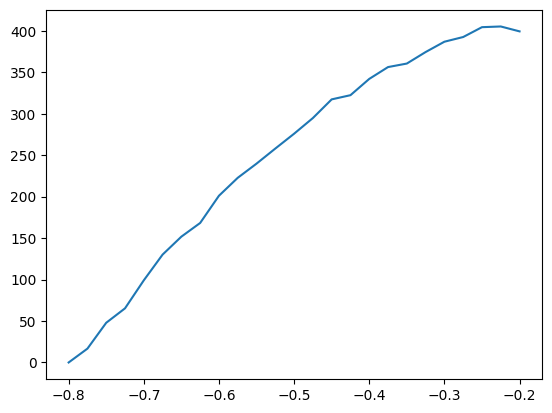

In [70]:
plt.plot(zpl_calibration['setpoint'], zpl_calibration['freq'] - zpl_calibration['freq'][0])
plt.show()

In [25]:
zpl_calibration['freq']

[7187.868218415106, 7187.868218415106, 7187.868218415106, 7187.868218415106, 7187.868218415106, 7187.868218415106, 7187.868218415106, 7187.868218415106, 7187.868218415106, 7187.868218415106, 7022.235281390551, 7055.624754256467, 7055.624754256467, 7114.994967166472, 7142.765113638849, 7158.128052292073, 7186.5326245934775, 7204.537585649374, 7227.82054402541, 7237.596062495735]

In [26]:
res_atto3.best_values['center']

7237.596062495735

In [8]:
ao_electrodes_remote.setpoint = -0.5
ple_gui._mw.channel_comboBox.setCurrentText('APD4')
res= do_ple_scan(laser_scanner_logic, ple_gui, lines=1, in_range=current_range)

Rsquared 0.8834868700313482


In [ ]:
self.zpl_calibration['setpoint'] = np.linspace(v0 - dv/2, v0 + dv/2, 10)
self.zpl_calibration['freq'] = []
for _setpoint in self.zpl_calibration['setpoint']:
    self.ao_electrodes.setpoint = _setpoint
    res_atto3 = self.do_ple('bf', dw = 1.2) #1.2 GHz
    self.zpl_calibration['freq'].append(res_atto3.freq)
    
self.zpl_calibration['freq'] = np.array(self.zpl_calibration['freq'])

In [53]:
ao_electrodes_remote.setpoint = -0.5

In [34]:
ao_electrodes_remote.setpoint

-1.13

In [25]:
PLE_check_trigger(pulsestreamer, False)

In [31]:
measurement_g2.set_green_power('atto3', 20)

In [32]:
measurement_g2.measurement_mode('Off-res')

In [4]:
measurement_g2.measurement_mode('PLE')

AttributeError: 'CorrMeasurements' object has no attribute 'value'

In [ ]:
for i in range(3):
    res = do_ple_scan(lines=1, 
                    in_range = laser_scanner_logic.scan_ranges["a"])
    if res.rsquared > 0.5:
        save_ple(tag=f'{elapsed_time}', poi_name='')
        break


TypeError: measurement_mode() got an unexpected keyword argument 'ibeam_smart'

In [ ]:
PLE_check_trigger(enable=True)
measurement_mode('PLE')


PLE_check_trigger(enable=False)
measurement_mode('Off-res')